In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Can define a custom RMSE function
def rmse(y_true, y_pred):
    output = mean_squared_error(y_true, y_pred)
    return np.sqrt(output)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
data = pd.read_csv('mpg.csv')
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    int64  
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 28.1 KB


In [4]:
df_clean=(
    data.drop(columns=['origin','car name','cylinders']) # Drop non-numeric columns
    .dropna() # Drop rows with missing values
    .reset_index(drop=True) # Reset index after dropping rows
)

df_clean.head()

,mpg,displacement,horsepower,weight,acceleration,model_year
0,18.0,307.0,130,3504,12.0,70
1,15.0,350.0,165,3693,11.5,70
2,18.0,318.0,150,3436,11.0,70
3,16.0,304.0,150,3433,12.0,70
4,17.0,302.0,140,3449,10.5,70


In [5]:
TARGET = 'mpg'
quan_candidates = ['displacement', 'horsepower', 'weight', 'acceleration', 'model_year'];

In [6]:
# df_clean[TARGET]
df_clean[quan_candidates]

,displacement,horsepower,weight,acceleration,model_year
0,307.0,130,3504,12.0,70
1,350.0,165,3693,11.5,70
2,318.0,150,3436,11.0,70
3,304.0,150,3433,12.0,70
4,302.0,140,3449,10.5,70
...,...,...,...,...,...
393,140.0,86,2790,15.6,82
394,97.0,52,2130,24.6,82
395,135.0,84,2295,11.6,82
396,120.0,79,2625,18.6,82


In [7]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,398.0,103.783920,38.599912,46.0,75.000,92.0,125.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


In [8]:
# Univariate Analysis
cols = [TARGET] + quan_candidates

<h2>Univariate Analysis</h2>

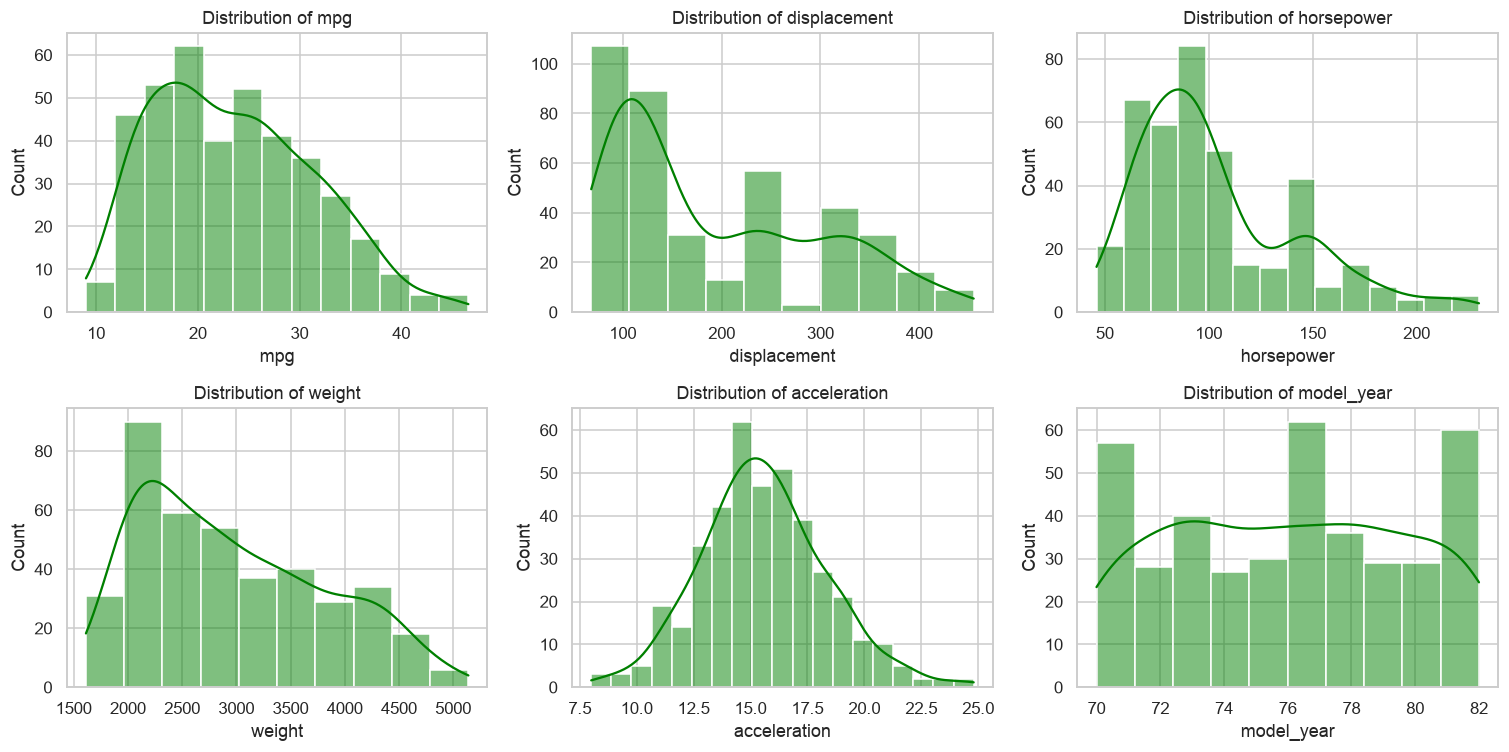

In [9]:
fig, axes = plt.subplots(2,3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.histplot(df_clean[c], ax=axes[i], kde=True, color='green',)
    axes[i].set_title(f'Distribution of {c}')
plt.tight_layout()
plt.show()

Skewness - having a tail (Right Skewed distribution) (48 min)

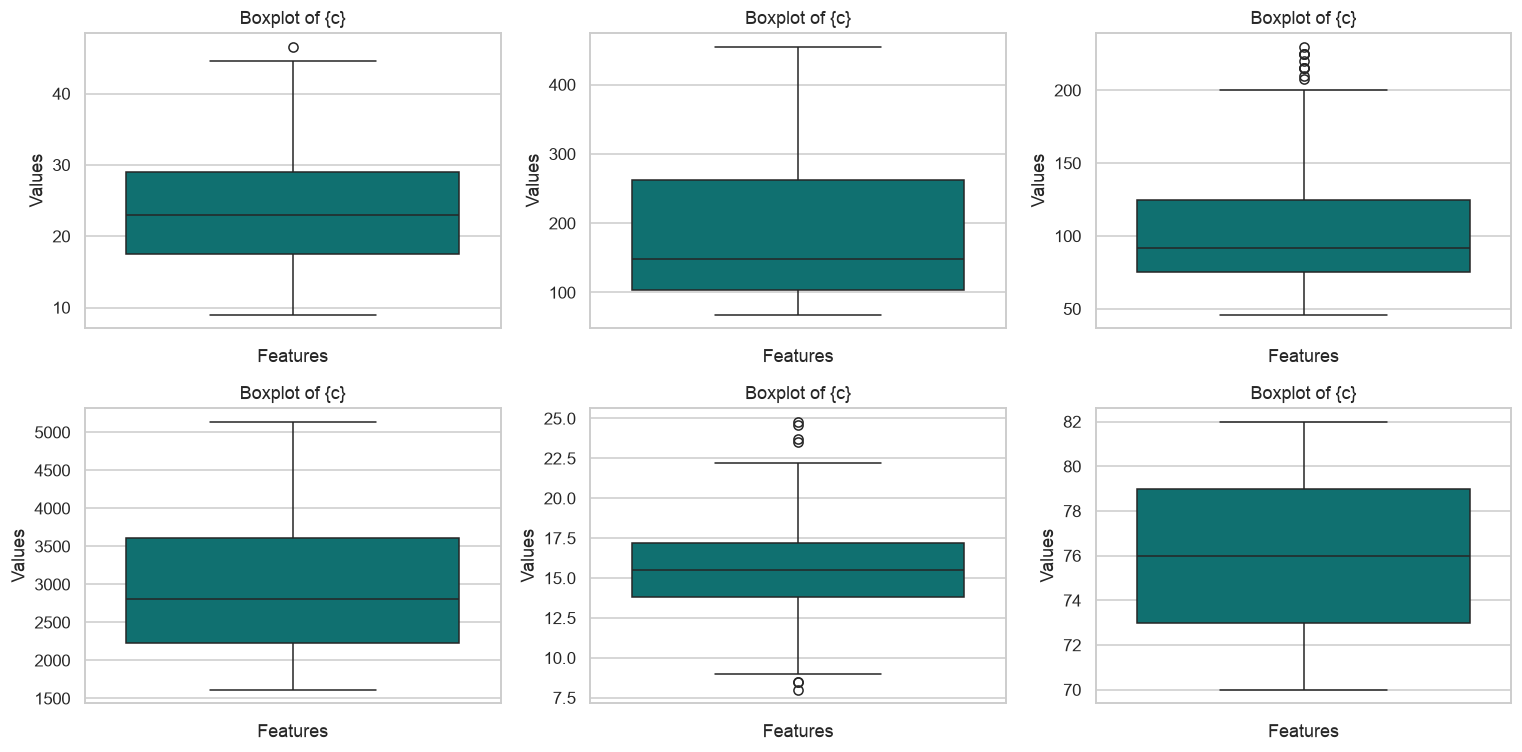

In [10]:
# plt.Figure(figsize=(14, 7))
# sns.boxplot(data=df_clean,  palette='crest')
# plt.title('Boxplot of Quantitative Features')
# plt.xlabel('Features')
# plt.ylabel('Values')
# plt.show()


fig, axes = plt.subplots(2,3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.boxplot(data=df_clean[c], ax=axes[i], color='teal')
    axes[i].set_title('Boxplot of {c}')
    axes[i].set_xlabel('Features')
    axes[i].set_ylabel('Values')
plt.tight_layout()
plt.show()

In [11]:
df_clean.skew().sort_values(ascending=False)

horsepower      1.090506
displacement    0.719645
weight          0.531063
mpg             0.457066
acceleration    0.278777
model_year      0.011535
dtype: float64

<h2>Bi variate Analysis</h2>

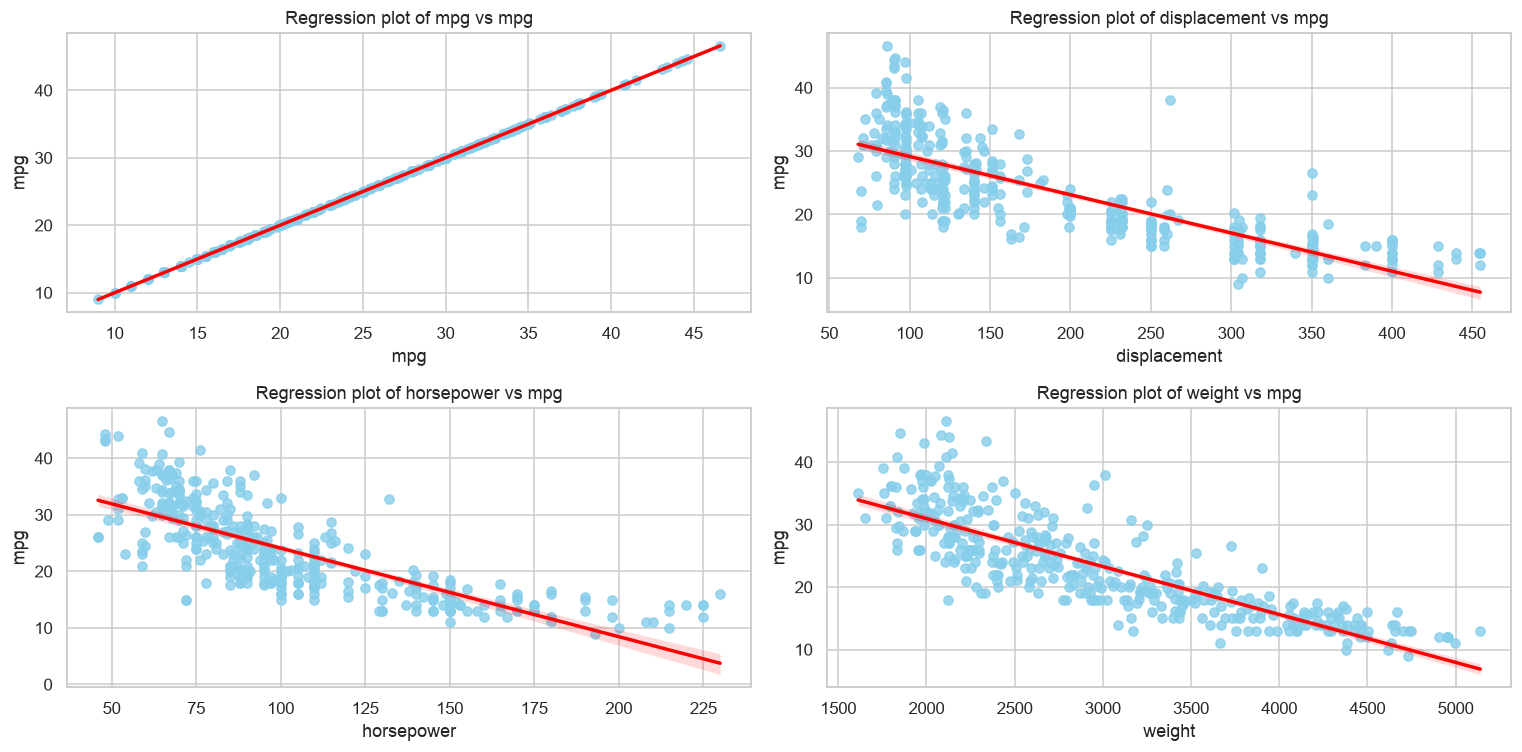

In [12]:
fig, axes = plt.subplots(2,2, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols[:4]):
    # sns.scatterplot(data=df_clean, x=c, y=TARGET, ax=axes[i], color='purple')
    sns.regplot(data=df_clean, x=c, y=TARGET, ax=axes[i], color='skyblue', line_kws={'color':'red'})
    axes[i].set_title(f'Regression plot of {c} vs {TARGET}')
plt.tight_layout()
plt.show()

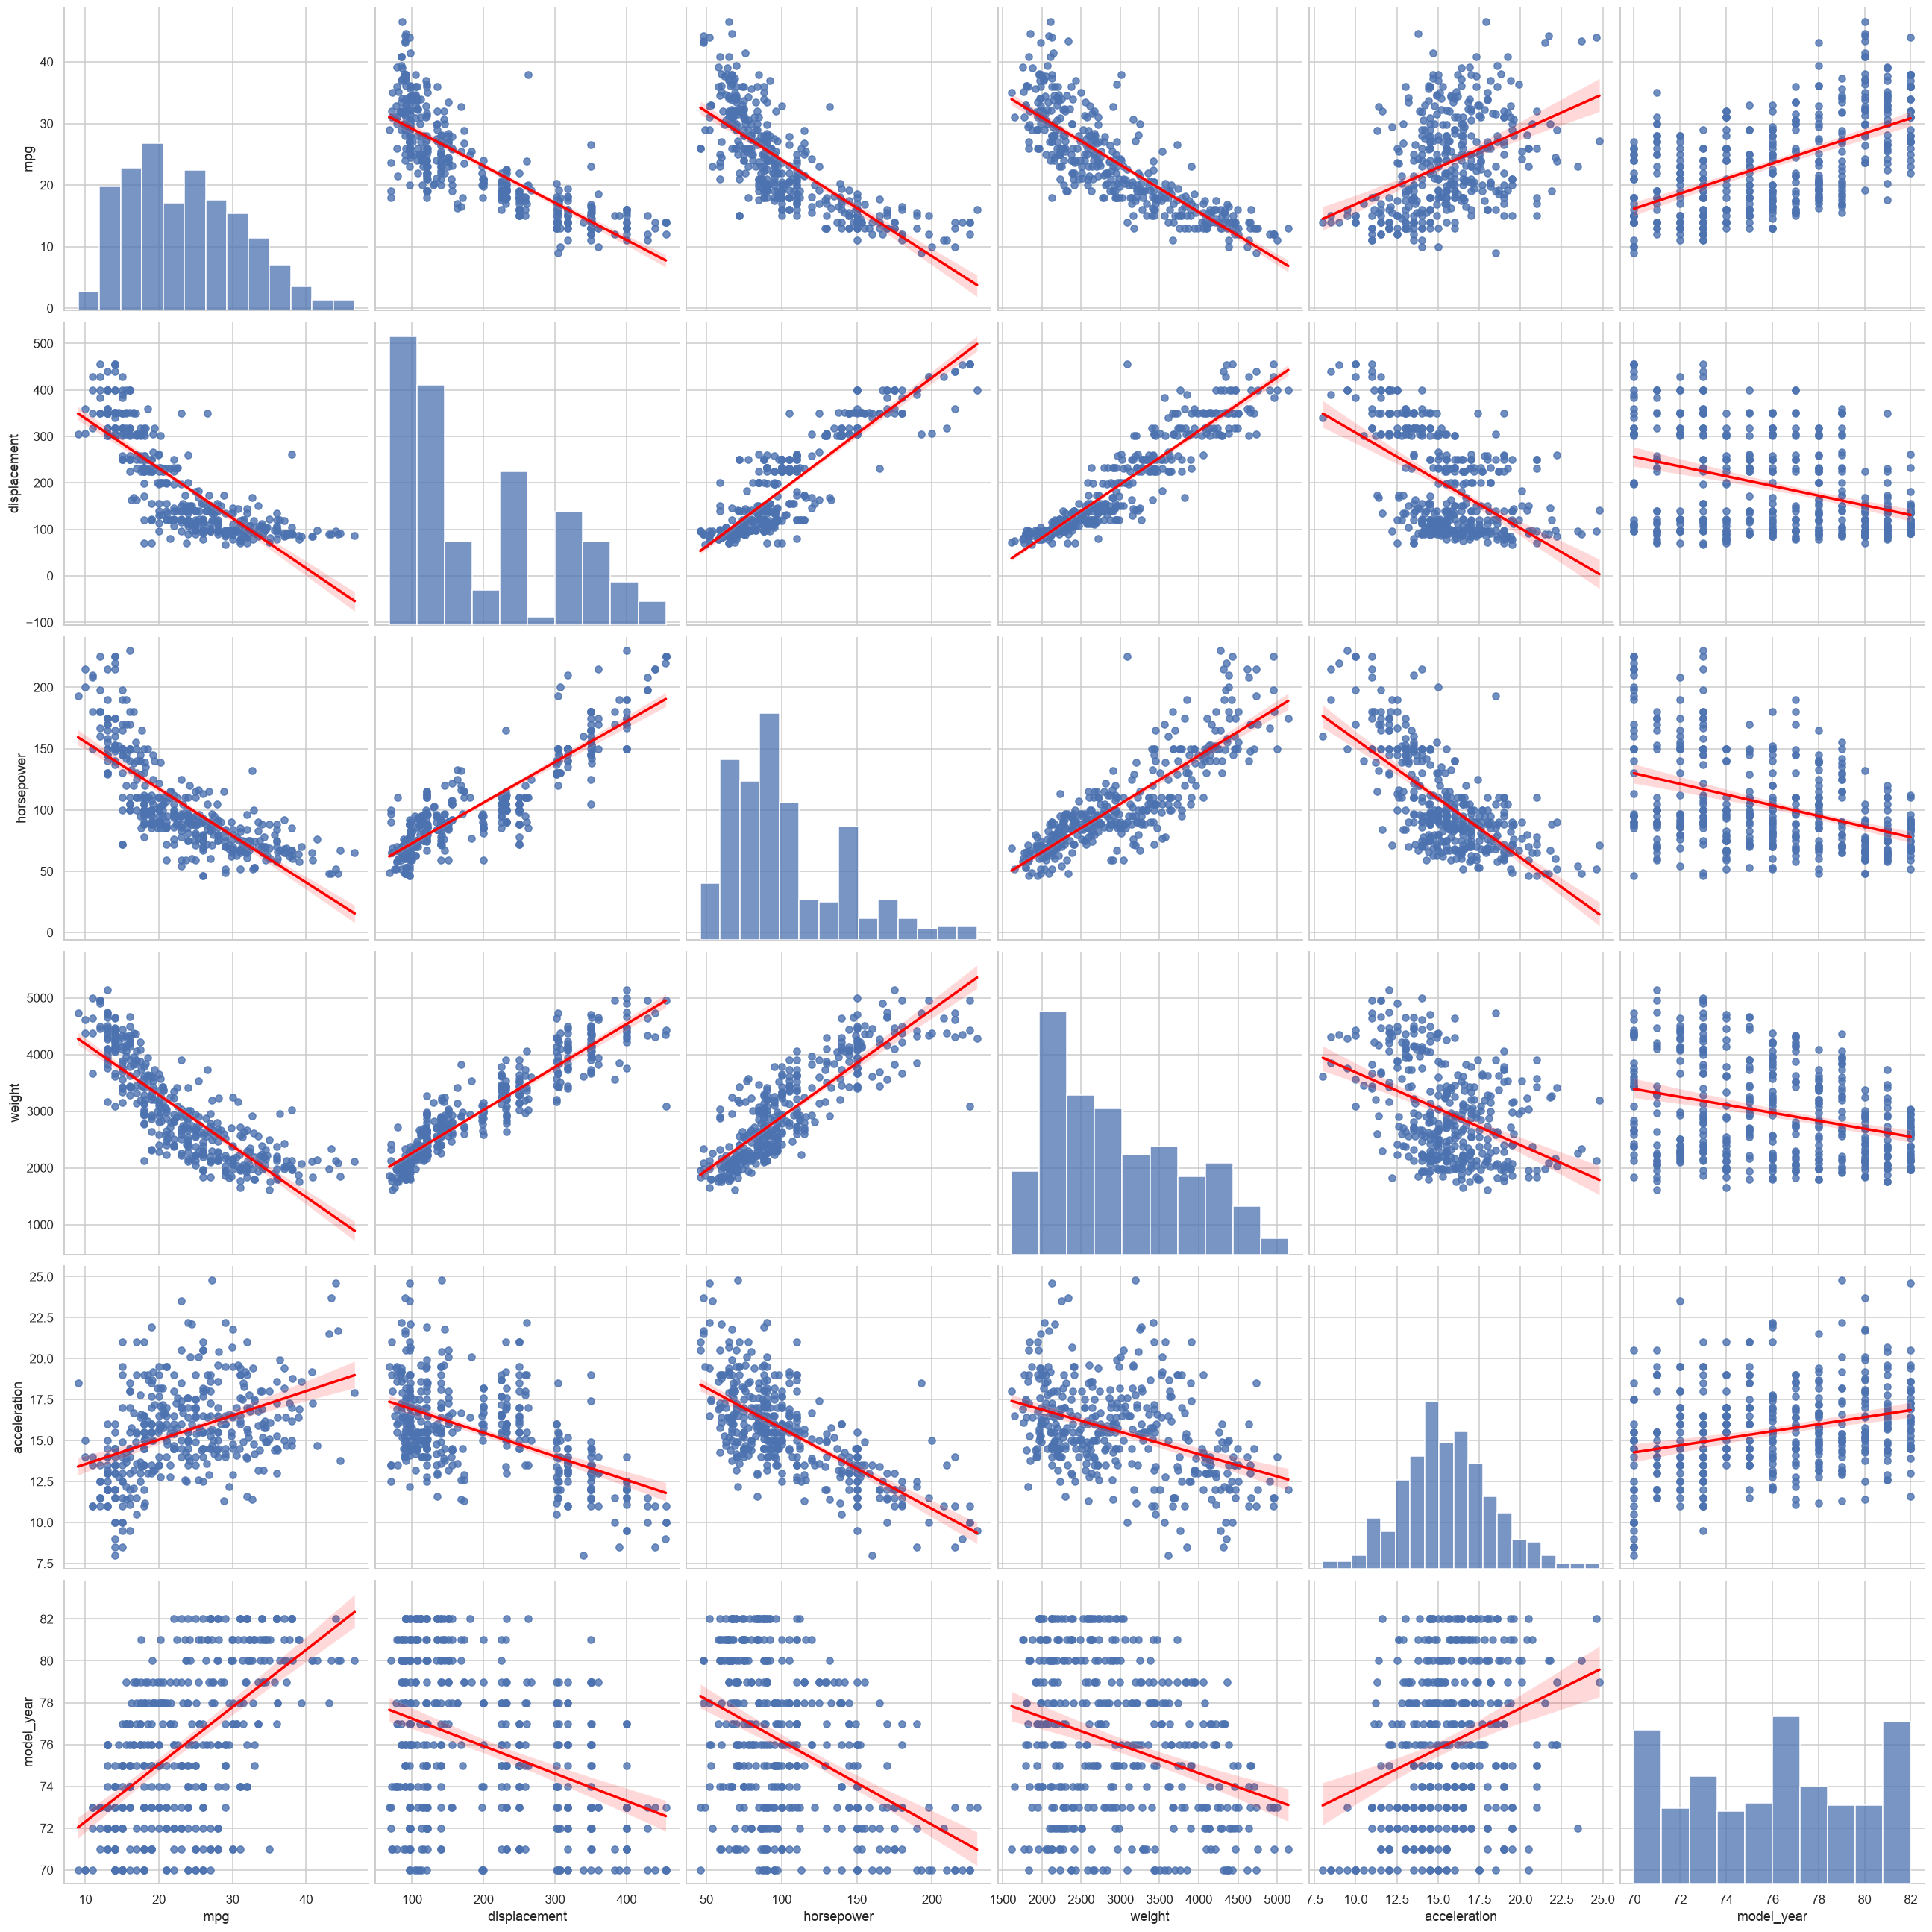

In [13]:
sns.pairplot(df_clean, vars=cols,  y_vars=[TARGET], height=4, aspect=1, kind='reg', plot_kws={'line_kws':{'color':'red'}})

## Correlation analysis

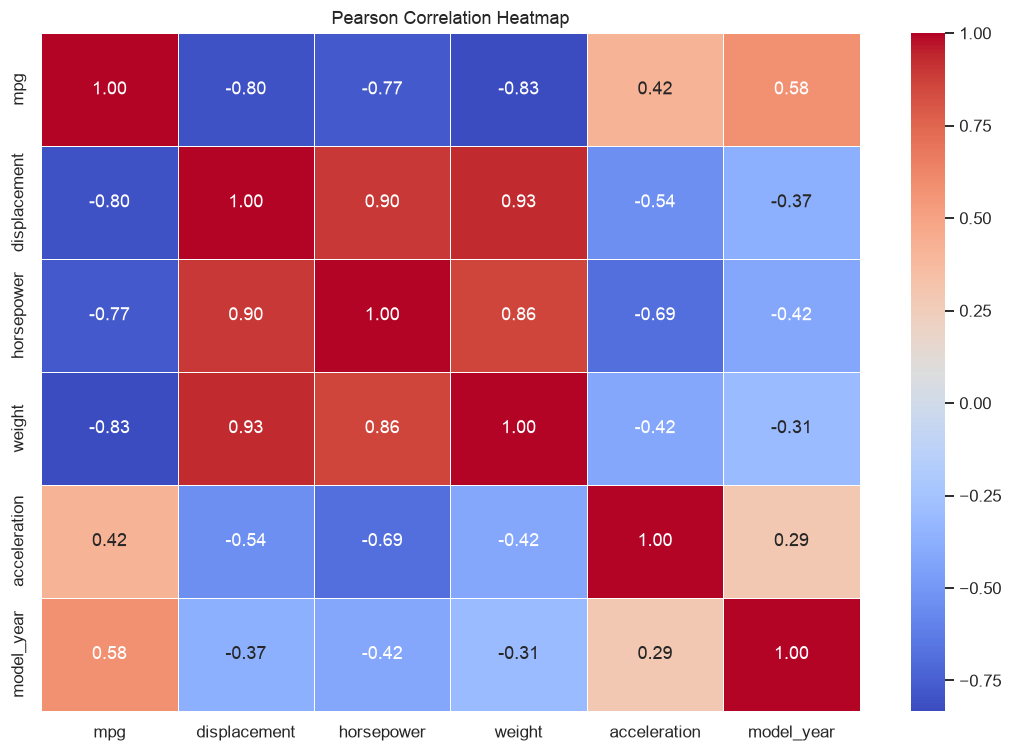

In [15]:
#Heatmap of pearson correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.show()

In [18]:
df_clean.corr()

,mpg,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.804203,-0.773645,-0.831741,0.420289,0.579267
displacement,-0.804203,1.000000,0.895369,0.932824,-0.543684,-0.370164
horsepower,-0.773645,0.895369,1.000000,0.861474,-0.688444,-0.416958
weight,-0.831741,0.932824,0.861474,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.543684,-0.688444,-0.417457,1.000000,0.288137
model_year,0.579267,-0.370164,-0.416958,-0.306564,0.288137,1.000000


### Linear Regression

In [19]:
TARGET = 'mpg' #Y
quan_candidates = ['displacement', 'horsepower', 'weight', 'acceleration', 'model_year'] #X

df_clean

,mpg,displacement,horsepower,weight,acceleration,model_year
0,18.0,307.0,130,3504,12.0,70
1,15.0,350.0,165,3693,11.5,70
2,18.0,318.0,150,3436,11.0,70
3,16.0,304.0,150,3433,12.0,70
4,17.0,302.0,140,3449,10.5,70
...,...,...,...,...,...,...
393,27.0,140.0,86,2790,15.6,82
394,44.0,97.0,52,2130,24.6,82
395,32.0,135.0,84,2295,11.6,82
396,28.0,120.0,79,2625,18.6,82


In [24]:
Y = df_clean[TARGET].values
X = df_clean[quan_candidates].values
X

array([[ 307. ,  130. , 3504. ,   12. ,   70. ],
       [ 350. ,  165. , 3693. ,   11.5,   70. ],
       [ 318. ,  150. , 3436. ,   11. ,   70. ],
       ...,
       [ 135. ,   84. , 2295. ,   11.6,   82. ],
       [ 120. ,   79. , 2625. ,   18.6,   82. ],
       [ 119. ,   82. , 2720. ,   19.4,   82. ]], shape=(398, 5))

In [28]:
# Train : Test   = 70:30
# For huge volumes : 99:1 or 99.9:0.1

train_size = 0.8
test_size = 0.2
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, test_size=test_size, random_state=42)


In [30]:
#Train the model

model = LinearRegression()
model.fit(X_train, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. , 0. ,-0.01, 0.08, 0.8 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.53
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[15074.5 , 698.73, 291.48, 57.02, 30.78]"


In [32]:
model.coef_.tolist()

[0.0026070790837978033,
 0.0027931429940157505,
 -0.007032029854926168,
 0.08043162551324153,
 0.8011230646354823]

In [33]:
model.intercept_

np.float64(-18.52690281074377)

In [37]:
coefficients = pd.DataFrame({
    'Feature': quan_candidates, 
    'Coefficient': model.coef_.tolist()
    })   
coefficients 

,Feature,Coefficient
0,displacement,0.002607
1,horsepower,0.002793
2,weight,-0.007032
3,acceleration,0.080432
4,model_year,0.801123


In [38]:
Y_pred = model.predict(X_test)
Y_pred

array([31.52074757, 30.73564614, 21.76023592, 16.96197253, 12.57465158,
       26.21250022, 28.95946184,  9.29080797, 17.12281913, 22.59266703,
       12.7095236 , 34.97810898, 26.68682894, 14.00221646, 24.82259851,
        5.93536757, 30.89011396, 23.74808936, 15.92279559, 35.1548642 ,
       23.47203557, 19.65821157, 29.32940311, 30.33429868, 15.04014048,
       34.56371299, 25.7811001 , 25.8181829 , 22.20379553,  7.97062427,
       29.40575992, 34.95280913, 19.9980337 , 24.94163255, 33.09011584,
       12.32141215, 24.40090942, 22.13785629, 12.34153792, 26.96657616,
       27.58514278, 27.40476816, 20.32356143,  7.7640109 , 23.28173396,
       33.70090865, 26.60021457, 24.49727025, 22.79467906, 27.68519676,
       23.51400514, 32.50188414, 31.30699538, 10.63724595, 28.97349296,
        9.41844886, 19.45875272, 28.34653109, 24.29538332, 20.74362898,
       16.48971482, 30.72766767, 24.96395982, 20.32981053, 21.60252246,
       24.37146354, 25.9309337 , 33.72360475, 29.34175875, 12.62

In [39]:
# Y_test, Y_pred
eval =rmse(Y_test, Y_pred)
eval

np.float64(3.062274280709524)

In [41]:
mse = mean_squared_error(Y_test, Y_pred)
mse

9.377523770295031

In [42]:
mae = mean_absolute_error(Y_test, Y_pred)
mae

2.459464274266824